In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
np.random.seed(42)

n_days = 150
dates = pd.date_range(start="2024-01-01", periods=n_days, freq="D")

t = np.arange(n_days)

trend = 50 + 0.2 * t
seasonality = 8 * np.sin(2 * np.pi * t / 7)
noise = np.random.normal(loc=0, scale=3, size=n_days)

sales = trend + seasonality + noise

df = pd.DataFrame({
    "date": dates,
    "sales": sales
})

df.head()

,date,sales
0,2024-01-01,51.490142
1,2024-01-02,56.039859
2,2024-01-03,60.142489
3,2024-01-04,58.640159
4,2024-01-05,46.626470


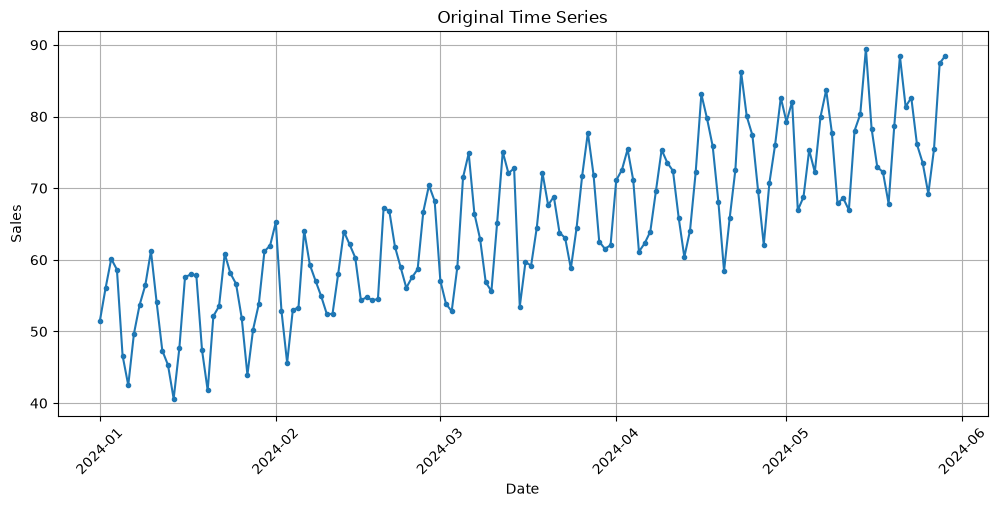

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["sales"], marker="o", markersize=3)
plt.title("Original Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [4]:
simple_series = np.array([10, 12, 13, 15, 18, 20, 21, 23])

window_size = 3

X_list = []
y_list = []

for i in range(len(simple_series) - window_size):
    X_window = simple_series[i : i + window_size]
    y_target = simple_series[i + window_size]
    
    X_list.append(X_window)
    y_list.append(y_target)

X_simple = np.array(X_list)
y_simple = np.array(y_list)

print("X:")
print(X_simple)

print("y:")
print(y_simple)

X:
[[10 12 13]
 [12 13 15]
 [13 15 18]
 [15 18 20]
 [18 20 21]]
y:
[15 18 20 21 23]


In [5]:
def create_sliding_windows(series, window_size, horizon=1):
    """
    把一条时间序列切成滑动窗口样本。

    参数：
    series: 一维时间序列，例如 [y1, y2, y3, ...]
    window_size: 输入窗口长度，例如用过去 7 天预测未来
    horizon: 预测步长
             horizon=1 表示预测下一个时间点
             horizon=3 表示预测未来第 3 个时间点

    返回：
    X: shape = [样本数, window_size]
    y: shape = [样本数]
    """
    
    X = []
    y = []
    
    for i in range(len(series) - window_size - horizon + 1):
        X_window = series[i : i + window_size]
        y_target = series[i + window_size + horizon - 1]
        
        X.append(X_window)
        y.append(y_target)
    
    return np.array(X), np.array(y)

In [6]:
series = df["sales"].values

window_size = 7
horizon = 1

X, y = create_sliding_windows(series, window_size=window_size, horizon=horizon)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (143, 7)
y shape: (143,)


In [7]:
for i in range(5):
    print(f"样本 {i + 1}")
    print("X:", X[i])
    print("y:", y[i])
    print("-" * 50)

样本 1
X: [51.49014246 56.03985896 60.14248891 58.64015948 46.62646996 42.49816583
 49.68298659]
y: 53.70230418745872
--------------------------------------------------
样本 2
X: [56.03985896 60.14248891 58.64015948 46.62646996 42.49816583 49.68298659
 53.70230419]
y: 56.44622870193938
--------------------------------------------------
样本 3
X: [60.14248891 58.64015948 46.62646996 42.49816583 49.68298659 53.70230419
 56.4462287 ]
y: 61.22710342821248
--------------------------------------------------
样本 4
X: [58.64015948 46.62646996 42.49816583 49.68298659 53.70230419 56.4462287
 61.22710343]
y: 54.080816834503075
--------------------------------------------------
样本 5
X: [46.62646996 42.49816583 49.68298659 53.70230419 56.4462287  61.22710343
 54.08081683]
y: 47.331740826348785
--------------------------------------------------


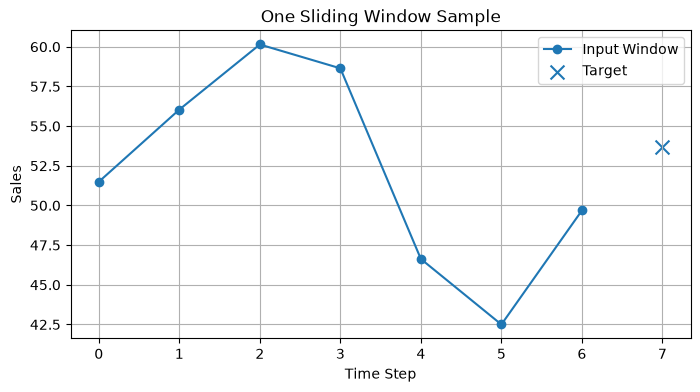

In [8]:
sample_idx = 0

x_sample = X[sample_idx]
y_sample = y[sample_idx]

plt.figure(figsize=(8, 4))
plt.plot(range(window_size), x_sample, marker="o", label="Input Window")
plt.scatter(window_size, y_sample, marker="x", s=100, label="Target")
plt.title("One Sliding Window Sample")
plt.xlabel("Time Step")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
for ws in [3, 7, 14, 30]:
    X_temp, y_temp = create_sliding_windows(series, window_size=ws, horizon=1)
    print(f"window_size = {ws}")
    print("X shape:", X_temp.shape)
    print("y shape:", y_temp.shape)
    print("-" * 40)

window_size = 3
X shape: (147, 3)
y shape: (147,)
----------------------------------------
window_size = 7
X shape: (143, 7)
y shape: (143,)
----------------------------------------
window_size = 14
X shape: (136, 14)
y shape: (136,)
----------------------------------------
window_size = 30
X shape: (120, 30)
y shape: (120,)
----------------------------------------


In [10]:
for h in [1, 3, 7]:
    X_temp, y_temp = create_sliding_windows(series, window_size=7, horizon=h)
    print(f"horizon = {h}")
    print("第一个 X:", X_temp[0])
    print("第一个 y:", y_temp[0])
    print("X shape:", X_temp.shape)
    print("y shape:", y_temp.shape)
    print("-" * 60)

horizon = 1
第一个 X: [51.49014246 56.03985896 60.14248891 58.64015948 46.62646996 42.49816583
 49.68298659]
第一个 y: 53.70230418745872
X shape: (143, 7)
y shape: (143,)
------------------------------------------------------------
horizon = 3
第一个 X: [51.49014246 56.03985896 60.14248891 58.64015948 46.62646996 42.49816583
 49.68298659]
第一个 y: 61.22710342821248
X shape: (141, 7)
y shape: (141,)
------------------------------------------------------------
horizon = 7
第一个 X: [51.49014246 56.03985896 60.14248891 58.64015948 46.62646996 42.49816583
 49.68298659]
第一个 y: 40.60550740628237
X shape: (137, 7)
y shape: (137,)
------------------------------------------------------------


In [11]:
train_size = int(len(series) * 0.8)

train_series = series[:train_size]
test_series = series[train_size:]

print("原始序列长度:", len(series))
print("训练序列长度:", len(train_series))
print("测试序列长度:", len(test_series))

原始序列长度: 150
训练序列长度: 120
测试序列长度: 30


In [12]:
window_size = 7
horizon = 1

X_train, y_train = create_sliding_windows(
    train_series,
    window_size=window_size,
    horizon=horizon
)

X_test, y_test = create_sliding_windows(
    test_series,
    window_size=window_size,
    horizon=horizon
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (113, 7)
y_train shape: (113,)
X_test shape: (23, 7)
y_test shape: (23,)


In [13]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_test_tensor shape:", X_test_tensor.shape)
print("y_test_tensor shape:", y_test_tensor.shape)

X_train_tensor shape: torch.Size([113, 7])
y_train_tensor shape: torch.Size([113])
X_test_tensor shape: torch.Size([23, 7])
y_test_tensor shape: torch.Size([23])


In [14]:
X_train_rnn = X_train_tensor.unsqueeze(-1)
X_test_rnn = X_test_tensor.unsqueeze(-1)

print("MLP 输入形状:", X_train_tensor.shape)
print("RNN/LSTM/GRU 输入形状:", X_train_rnn.shape)

MLP 输入形状: torch.Size([113, 7])
RNN/LSTM/GRU 输入形状: torch.Size([113, 7, 1])


In [15]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        """
        X: 输入窗口
        y: 预测目标
        """
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [16]:
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

print("训练集样本数量:", len(train_dataset))
print("测试集样本数量:", len(test_dataset))

训练集样本数量: 113
测试集样本数量: 23


In [17]:
x0, y0 = train_dataset[0]

print("x0:", x0)
print("y0:", y0)

print("x0 shape:", x0.shape)
print("y0 shape:", y0.shape)

x0: tensor([51.4901, 56.0399, 60.1425, 58.6402, 46.6265, 42.4982, 49.6830])
y0: tensor(53.7023)
x0 shape: torch.Size([7])
y0 shape: torch.Size([])


In [18]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

for batch_X, batch_y in train_loader:
    print("batch_X shape:", batch_X.shape)
    print("batch_y shape:", batch_y.shape)
    break

batch_X shape: torch.Size([16, 7])
batch_y shape: torch.Size([16])


In [19]:
class TimeSeriesDatasetForRNN(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [20]:
train_rnn_dataset = TimeSeriesDatasetForRNN(X_train, y_train)

train_rnn_loader = DataLoader(
    train_rnn_dataset,
    batch_size=16,
    shuffle=False
)

for batch_X, batch_y in train_rnn_loader:
    print("RNN batch_X shape:", batch_X.shape)
    print("RNN batch_y shape:", batch_y.shape)
    break

RNN batch_X shape: torch.Size([16, 7, 1])
RNN batch_y shape: torch.Size([16])


In [21]:
X_train_tcn = X_train_tensor.unsqueeze(1)

print("MLP 输入形状:", X_train_tensor.shape)
print("RNN 输入形状:", X_train_tensor.unsqueeze(-1).shape)
print("TCN 输入形状:", X_train_tcn.shape)

MLP 输入形状: torch.Size([113, 7])
RNN 输入形状: torch.Size([113, 7, 1])
TCN 输入形状: torch.Size([113, 1, 7])


In [22]:
def prepare_time_series_data(series, window_size=7, horizon=1, train_ratio=0.8):
    """
    时间序列深度学习数据准备函数。

    步骤：
    1. 按时间顺序切分训练集和测试集
    2. 分别构造滑动窗口
    3. 转换成 PyTorch Tensor

    返回：
    X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor
    """
    
    train_size = int(len(series) * train_ratio)
    
    train_series = series[:train_size]
    test_series = series[train_size:]
    
    X_train, y_train = create_sliding_windows(
        train_series,
        window_size=window_size,
        horizon=horizon
    )
    
    X_test, y_test = create_sliding_windows(
        test_series,
        window_size=window_size,
        horizon=horizon
    )
    
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
    
    return X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor

In [23]:
X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor = prepare_time_series_data(
    series,
    window_size=7,
    horizon=1,
    train_ratio=0.8
)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_train_tensor: torch.Size([113, 7])
y_train_tensor: torch.Size([113])
X_test_tensor: torch.Size([23, 7])
y_test_tensor: torch.Size([23])
